In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/crop_recommendation.csv")

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.size

17600

In [6]:
df.shape

(2200, 8)

In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [9]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [12]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

EDA

In [13]:
import matplotlib.pyplot as plt

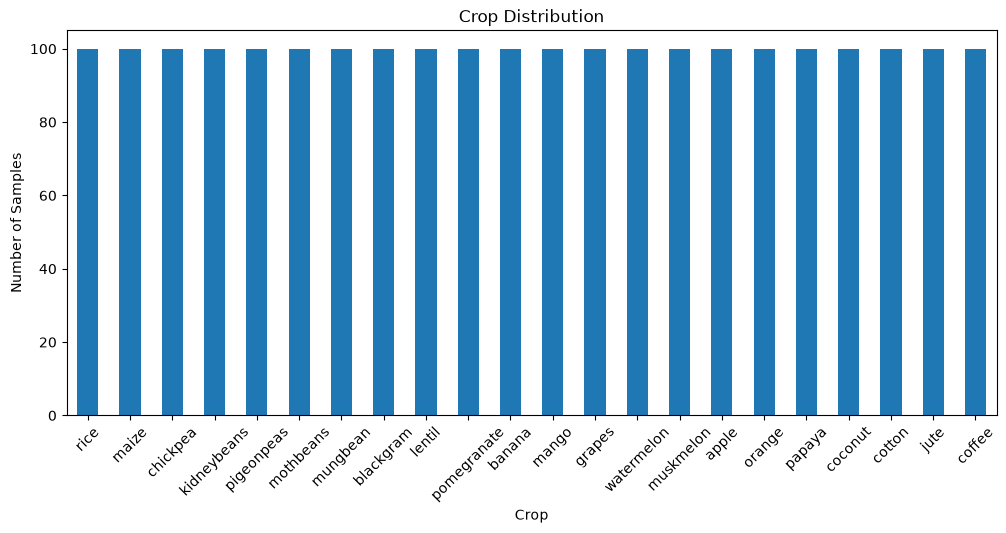

In [14]:
df["label"].value_counts().plot(kind="bar", figsize=(12, 5))
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.title("Crop Distribution")
plt.xticks(rotation=45)
plt.show()

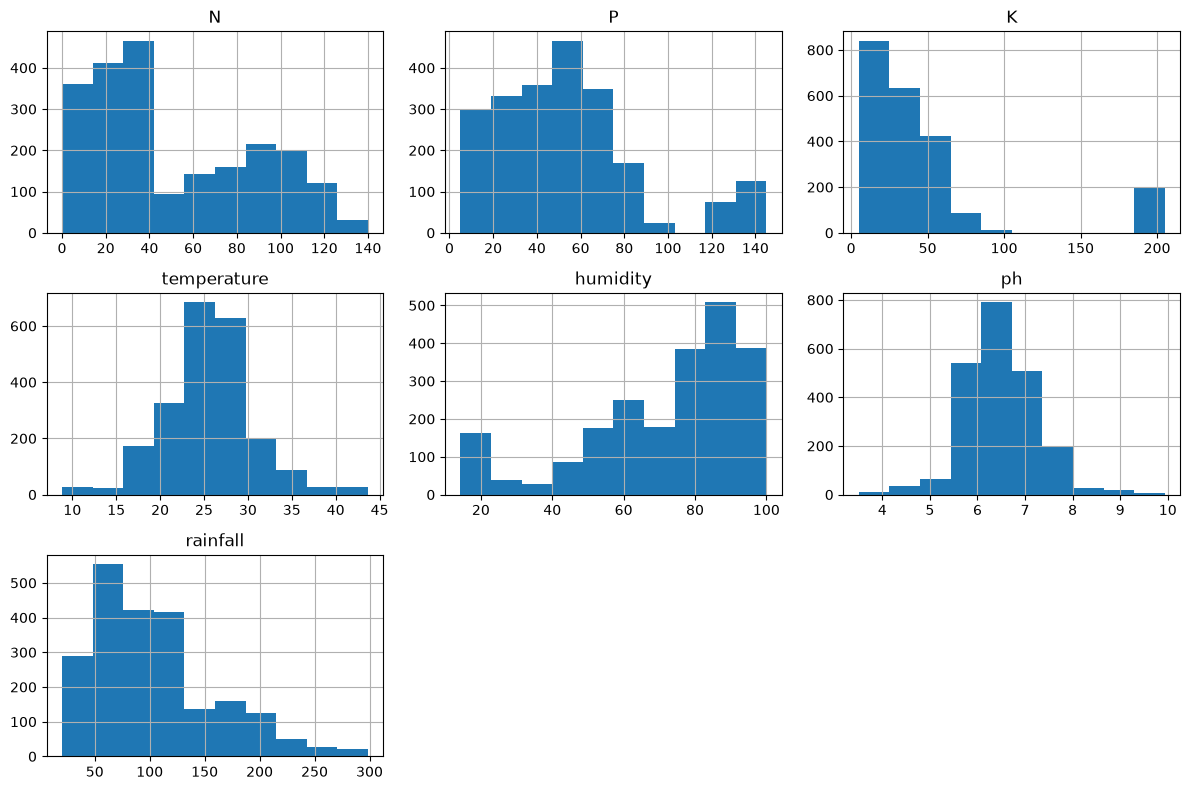

In [15]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [16]:
import seaborn as sns

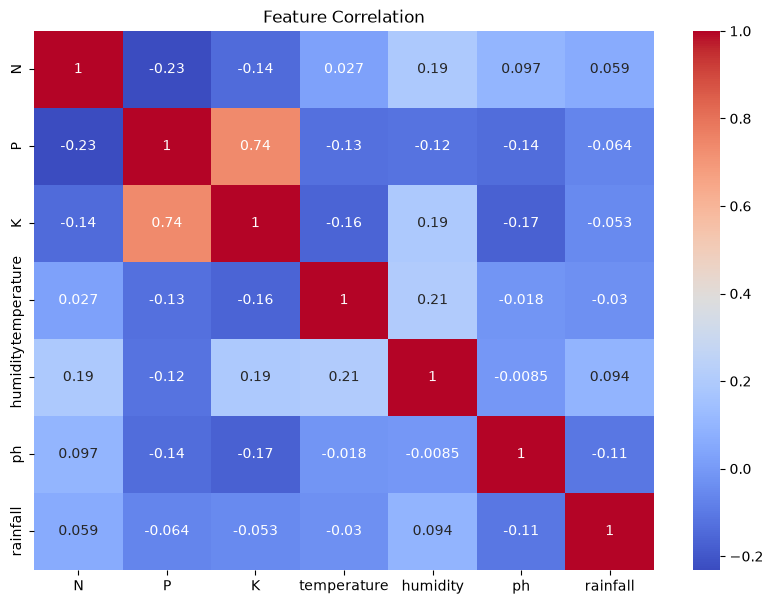

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [18]:
corr = df.select_dtypes(include="number").corr()

upper = corr.where(
    ~__import__("numpy").tril(
        __import__("numpy").ones(corr.shape)
    ).astype(bool)
)

print(upper.stack().sort_values(ascending=False))

P            K              0.736232
temperature  humidity       0.205320
K            humidity       0.190859
N            humidity       0.190688
             ph             0.096683
humidity     rainfall       0.094423
N            rainfall       0.059020
             temperature    0.026504
humidity     ph            -0.008483
temperature  ph            -0.017795
             rainfall      -0.030084
K            rainfall      -0.053461
P            rainfall      -0.063839
ph           rainfall      -0.109069
P            humidity      -0.118734
             temperature   -0.127541
             ph            -0.138019
N            K             -0.140512
K            temperature   -0.160387
             ph            -0.169503
N            P             -0.231460
             N                   NaN
P            N                   NaN
             P                   NaN
K            N                   NaN
             P                   NaN
             K                   NaN
t

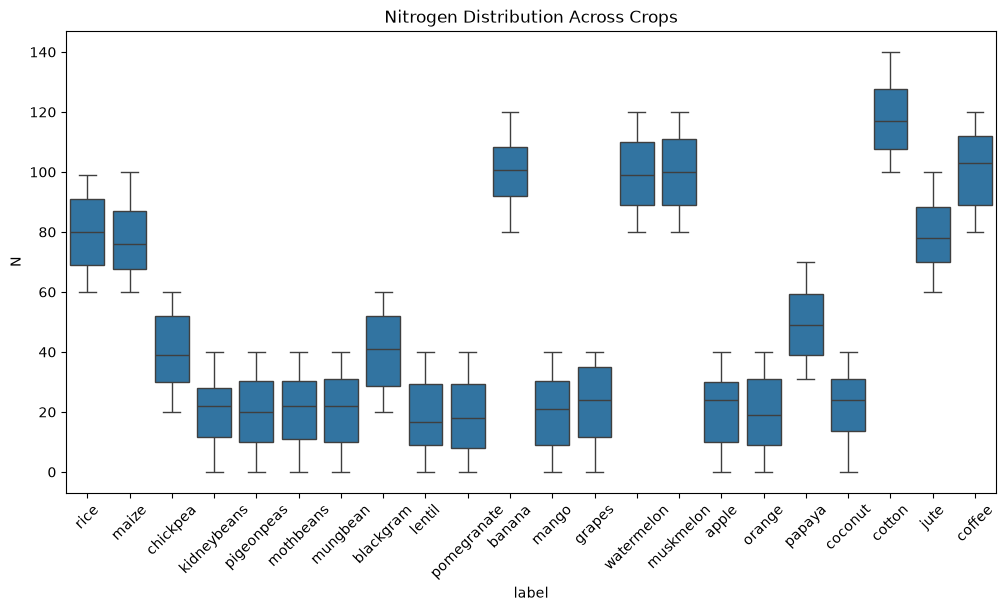

In [22]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x="label", y="N")

plt.xticks(rotation=45)
plt.title("Nitrogen Distribution Across Crops")
plt.show()

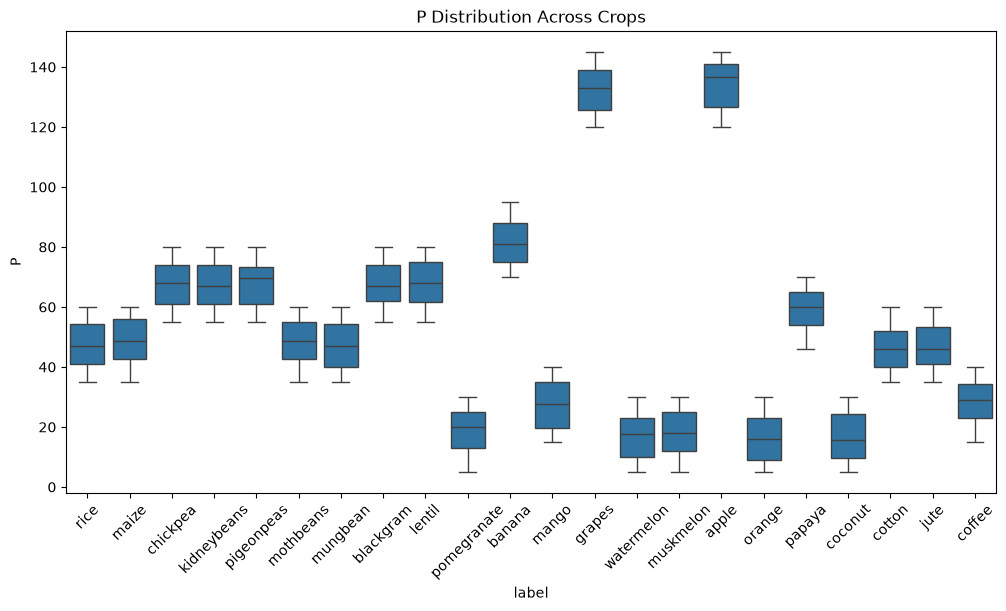

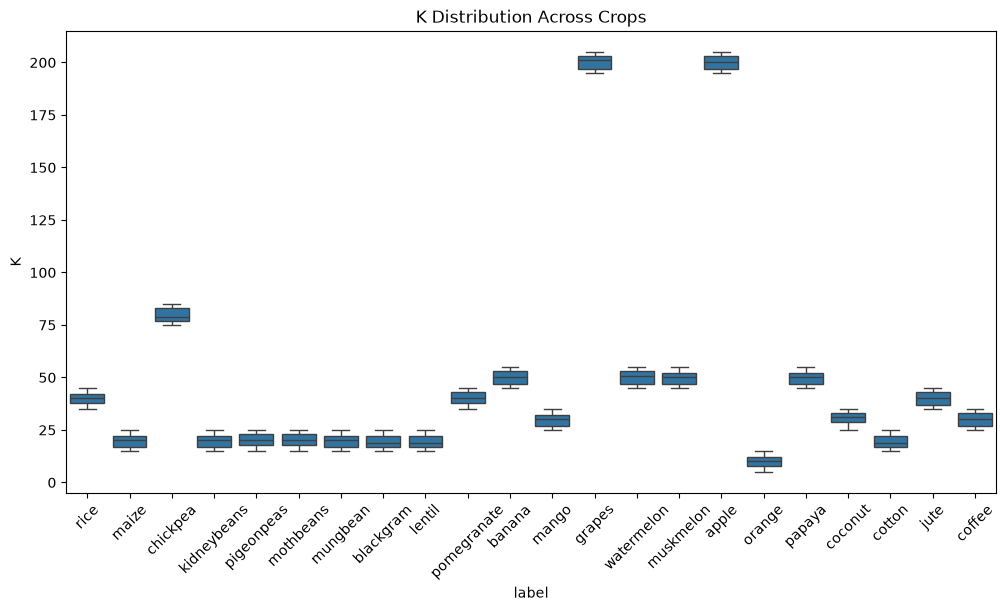

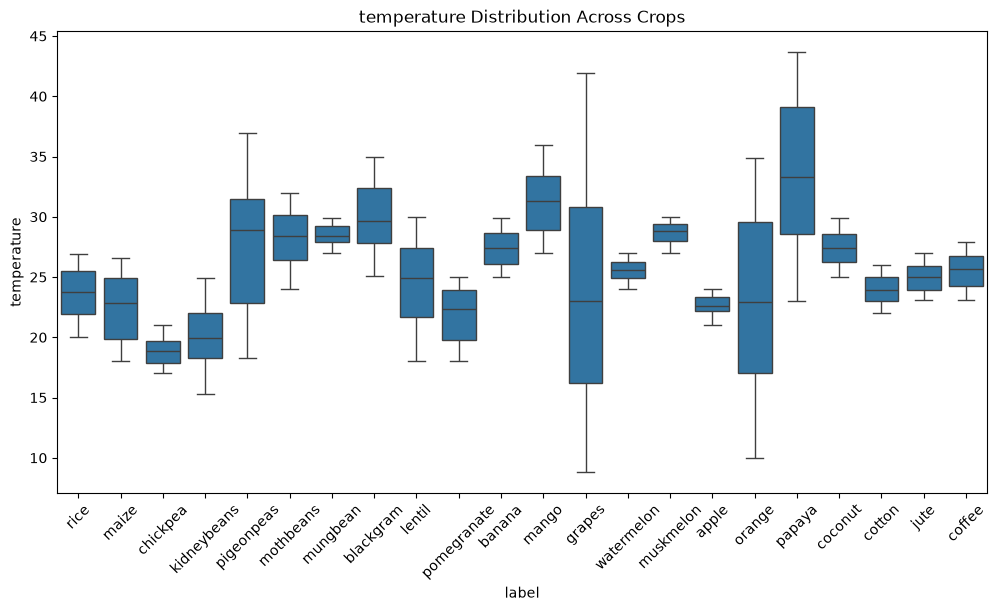

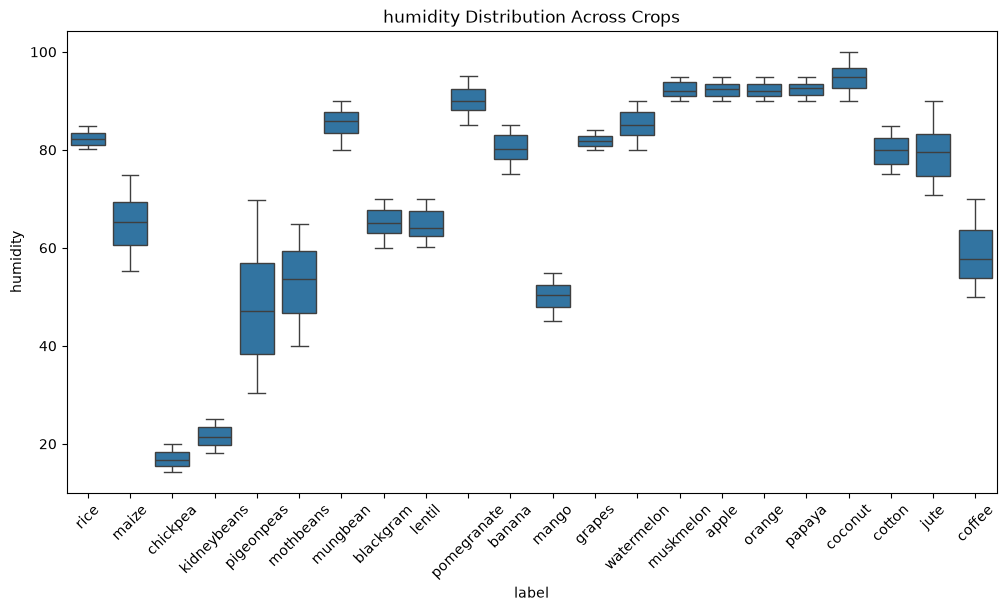

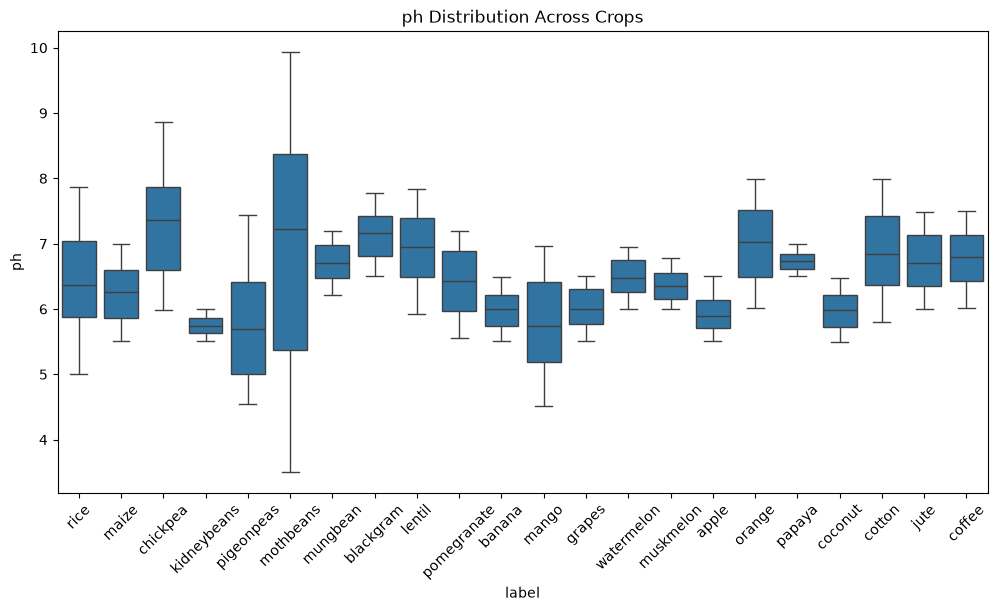

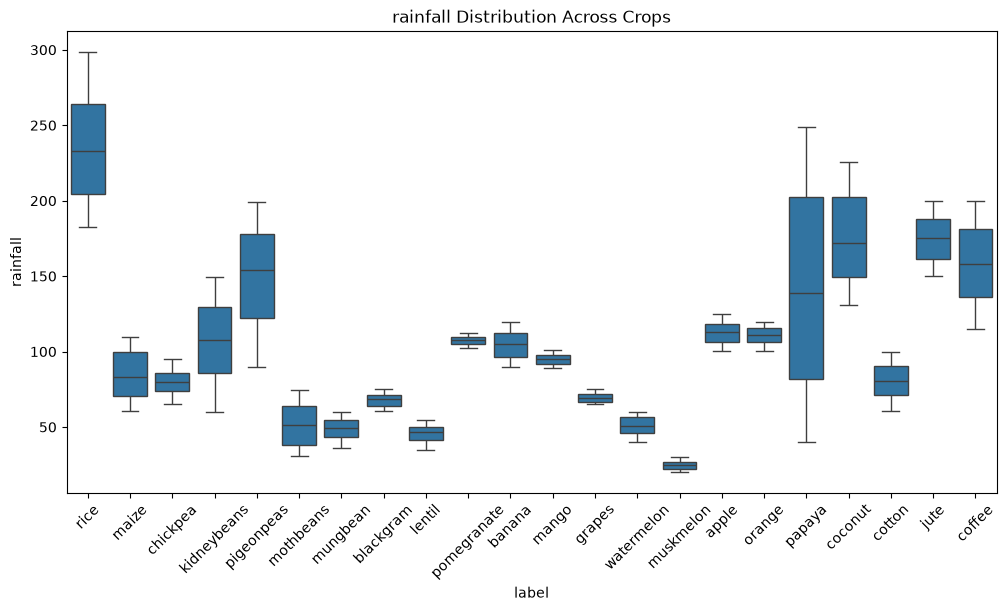

In [23]:
features = ["P", "K", "temperature", "humidity", "ph", "rainfall"]

for feature in features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="label", y=feature)
    plt.xticks(rotation=45)
    plt.title(f"{feature} Distribution Across Crops")
    plt.show()

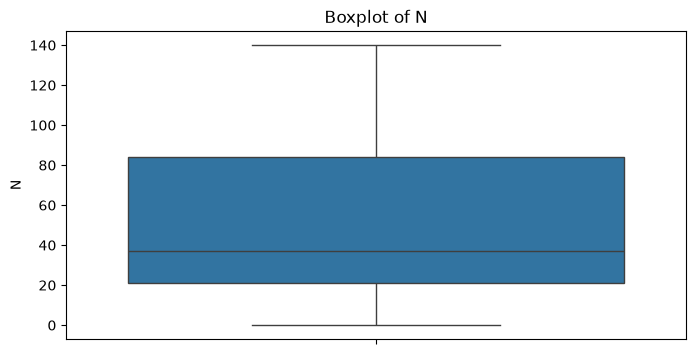

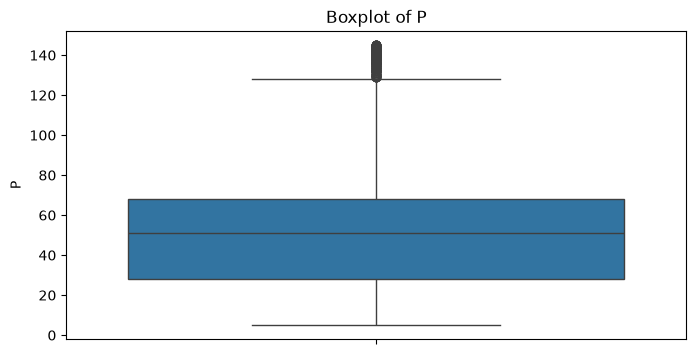

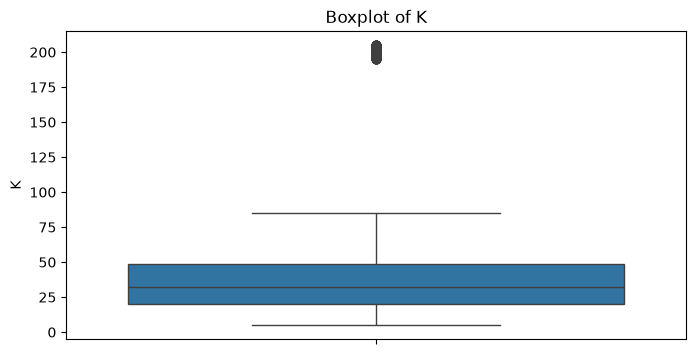

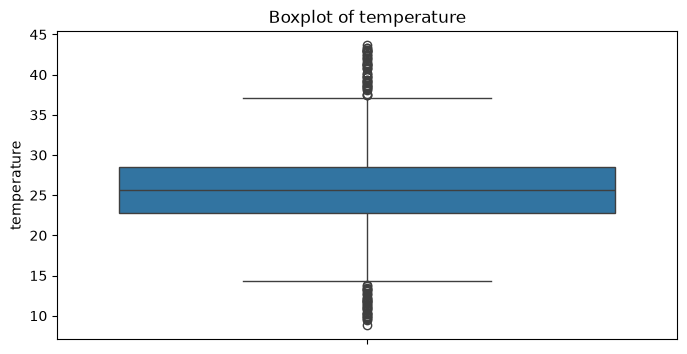

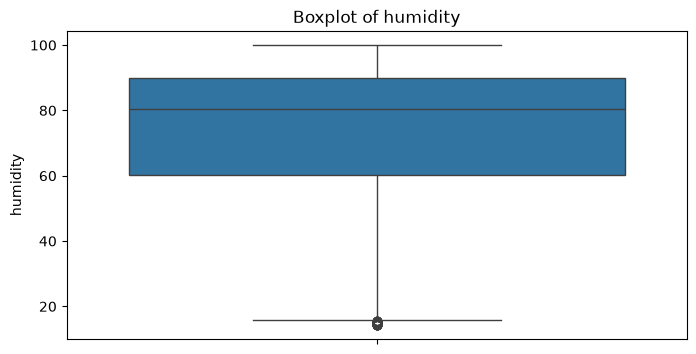

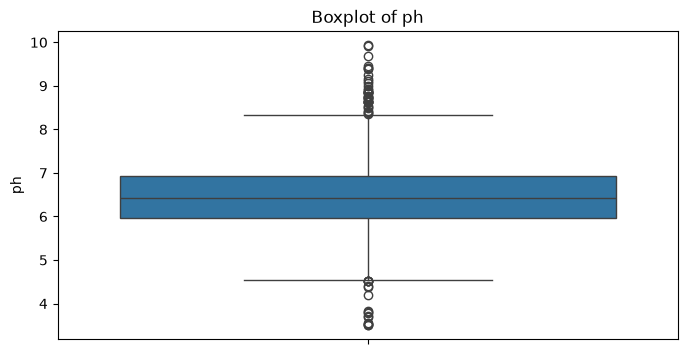

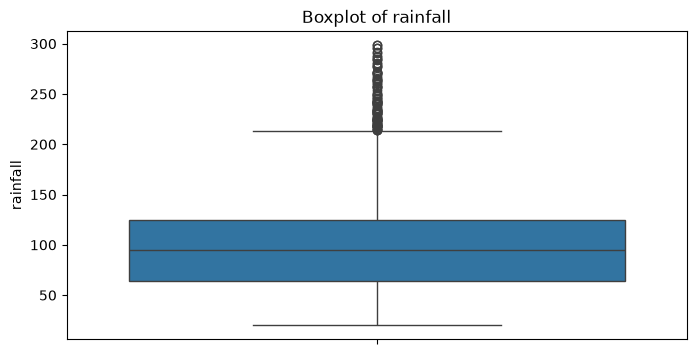

In [24]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.show()

In [27]:
features = ["temperature", "rainfall"]

for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]

    print(f"\n{feature}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))
    print(outliers[[feature, "label"]].sort_values(feature))


temperature
Lower bound: 14.080955682499999
Upper bound: 37.2500728825
Number of outliers: 86
      temperature   label
1214     8.825675  grapes
1211     9.467960  grapes
1293     9.535586  grapes
1291     9.724458  grapes
1295     9.851243  grapes
...           ...     ...
1766    43.037143  papaya
1750    43.080227  papaya
1722    43.302049  papaya
1761    43.360515  papaya
1743    43.675493  papaya

[86 rows x 2 columns]

rainfall
Lower bound: -25.022046700000033
Upper bound: 213.84124050000003
Number of outliers: 100
        rainfall    label
1886  213.901102  coconut
1748  214.410385   papaya
1855  214.412887  coconut
1867  215.196804  coconut
1814  215.919505  coconut
...          ...      ...
19    291.298662     rice
72    295.609449     rice
96    295.924880     rice
38    298.401847     rice
43    298.560117     rice

[100 rows x 2 columns]


In [28]:
Q1 = df["ph"].quantile(0.25)
Q3 = df["ph"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["ph"] < lower) | (df["ph"] > upper)]

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))

print(outliers[["ph", "label"]].sort_values("ph"))

Lower bound: 4.543768066249998
Upper bound: 8.351567354250005
Number of outliers: 57
            ph      label
557   3.504752  mothbeans
529   3.510404  mothbeans
582   3.525366  mothbeans
599   3.532009  mothbeans
561   3.558823  mothbeans
500   3.692864  mothbeans
521   3.711059  mothbeans
537   3.793575  mothbeans
526   3.808429  mothbeans
535   3.828031  mothbeans
538   4.193189  mothbeans
501   4.371746  mothbeans
575   4.397699  mothbeans
1128  4.507524      mango
541   4.516154  mothbeans
528   4.523636  mothbeans
517   4.524172  mothbeans
1195  4.525722      mango
586   8.354958  mothbeans
246   8.380185   chickpea
502   8.399136  mothbeans
287   8.423874   chickpea
213   8.490127   chickpea
222   8.519976   chickpea
577   8.532079  mothbeans
545   8.620108  mothbeans
597   8.621514  mothbeans
233   8.621663   chickpea
587   8.634930  mothbeans
596   8.639586  mothbeans
560   8.660780  mothbeans
572   8.709292  mothbeans
210   8.718193   chickpea
288   8.719961   chickpea
242  

Model Building

In [29]:
X = df.drop("label", axis=1)
y = df["label"]

1. Logistic Regression — baseline

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [33]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.96590909 0.95738636 0.96875    0.97159091 0.97727273]
Mean CV accuracy: 0.9681818181818181
Standard deviation: 0.006577180058403534


2. Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [35]:
scores = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.99431818 0.97727273 0.98863636 0.98863636 0.97727273]
Mean CV accuracy: 0.9852272727272728
Standard deviation: 0.006818181818181797


3. Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [37]:
scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [1.         0.99715909 0.98863636 0.98863636 0.99715909]
Mean CV accuracy: 0.9943181818181819
Standard deviation: 0.004753750150761795


Extra Trees

In [38]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [39]:
scores = cross_val_score(
    extra_trees_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.99715909 0.99147727 0.98579545 0.99147727 0.99147727]
Mean CV accuracy: 0.9914772727272727
Standard deviation: 0.0035934973411004276


Boosting

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

In [41]:
scores = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Fold scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Standard deviation:", scores.std())

Fold scores: [0.99147727 0.98295455 0.98295455 0.98863636 0.98863636]
Mean CV accuracy: 0.9869318181818182
Standard deviation: 0.0034090909090909245


Tune Random Forest

In [42]:
RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

GridSearchCV.

In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [44]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

In [45]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support fo

In [46]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV accuracy:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV accuracy:
0.9960227272727273


In [47]:
best_model = grid_search.best_estimator_

test_predictions = best_model.predict(X_test)

test_accuracy = (test_predictions == y_test).mean()

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9954545454545455


confusion matrix

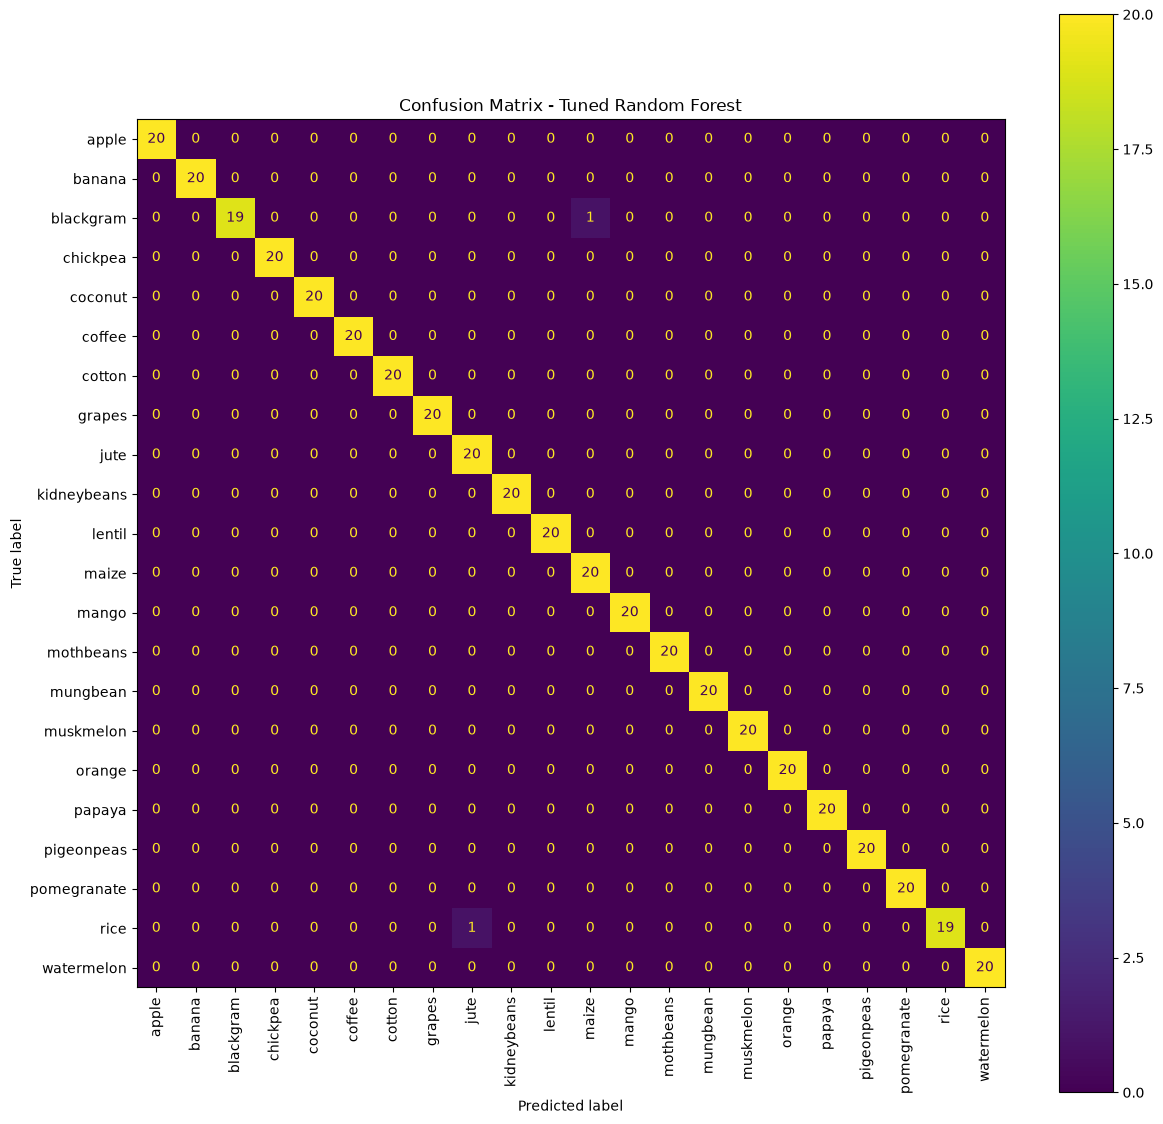

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=90)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

In [50]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": test_predictions
})

mistakes = results[results["Actual"] != results["Predicted"]]

print(mistakes)

        Actual Predicted
789  blackgram     maize
83        rice      jute


In [51]:
mistakes = X_test.copy()

mistakes["Actual"] = y_test
mistakes["Predicted"] = test_predictions

mistakes = mistakes[mistakes["Actual"] != mistakes["Predicted"]]

print(mistakes)

      N   P   K  temperature   humidity        ph    rainfall     Actual  \
789  60  59  22    31.868473  66.742175  7.191523   74.222386  blackgram   
83   67  43  39    26.043720  84.969072  5.999969  186.753677       rice   

    Predicted  
789     maize  
83       jute  


In [52]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_predictions
))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

Feature Importance

In [53]:
import pandas as pd

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

rainfall       0.220753
humidity       0.220182
K              0.178327
P              0.148808
N              0.106676
temperature    0.074563
ph             0.050691
dtype: float64


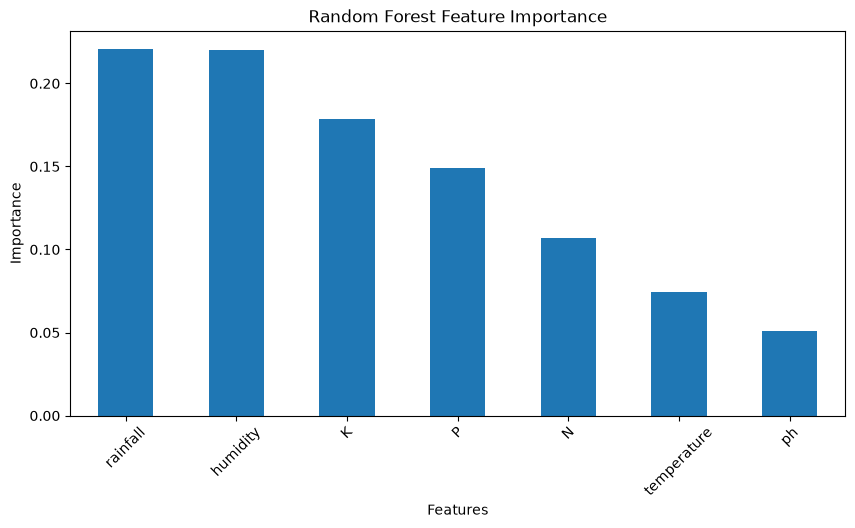

In [54]:
importance.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

If I randomly shuffle this feature, how much does the model's performance decrease?

In [55]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print(perm_importance)

humidity       0.330227
N              0.261591
rainfall       0.174545
K              0.152955
P              0.113636
temperature    0.008636
ph             0.007273
dtype: float64


feature-selection experiment

In [56]:
features_all = [
    "N", "P", "K", "temperature",
    "humidity", "ph", "rainfall"
]

features_no_ph = [
    "N", "P", "K", "temperature",
    "humidity", "rainfall"
]

features_core = [
    "N", "P", "K",
    "humidity", "rainfall"
]

In [57]:
X_train_all = X_train[features_all]
X_train_no_ph = X_train[features_no_ph]
X_train_core = X_train[features_core]

In [58]:
X_test_all = X_test[features_all]
X_test_no_ph = X_test[features_no_ph]
X_test_core = X_test[features_core]

Use our tuned Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [60]:
scores_all = cross_val_score(
    rf,
    X_train_all,
    y_train,
    cv=skf,
    scoring="accuracy"
)

scores_no_ph = cross_val_score(
    rf,
    X_train_no_ph,
    y_train,
    cv=skf,
    scoring="accuracy"
)

scores_core = cross_val_score(
    rf,
    X_train_core,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("All features:", scores_all.mean())
print("Without pH:", scores_no_ph.mean())
print("Core features:", scores_core.mean())

All features: 0.9960227272727273
Without pH: 0.9931818181818182
Core features: 0.990340909090909


What did we learn?

Even though pH and temperature had relatively low permutation importance, they still contain information that helps the model when combined with the other features.

Final model evaluation

In [61]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [62]:
final_predictions = final_model.predict(X_test)

print("Final Test Accuracy:",
      (final_predictions == y_test).mean())

Final Test Accuracy: 0.9954545454545455


Save the model

In [63]:
import joblib

joblib.dump(final_model, "crop_recommendation_model.pkl")

['crop_recommendation_model.pkl']

Verify that it was saved

In [64]:
import os

print(os.path.exists("crop_recommendation_model.pkl"))

True
